
# Inference without multiplying: how a 1.7-bit model works

On 3 Aug 2026, Syzygy Research announced **Mach-1 Additive** — a 35-billion-parameter
model that, they claim, *"can inference without ever multiplying by a weight"*, at
**1.7 bits per weight**, recovering **95%** of the original model's quality.

Three claims, and every one of them sounds impossible at first:

1. A neural network that runs **without multiplication**.
2. A weight stored in **1.7 bits** — less than two coin flips.
3. It still **works**.

This notebook takes each apart with a worked example you can run and tweak. By the
end you'll have built a multiply-free layer yourself, watched a real (tiny) network
break when you naively compress it, and then watched it heal — which is the part
that actually matters.

**The punchline up front:** the trick is not clever compression. It's that you
*restrict what a weight is allowed to be* until multiplication becomes unnecessary,
and then **retrain the network to cope**. Claim 3 is a consequence of the retraining,
not of the compression.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Patch

rng = np.random.default_rng(0)

# Palette roles (validated categorical + diverging set; light surface).
INK, INK2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
NEG, ZERO, POS = "#e34948", "#f0efec", "#2a78d6"   # diverging: -1 / 0 / +1
SEQ = LinearSegmentedColormap.from_list("seq", ["#cde2fb", "#3987e5", "#0d366b"])
TERN = ListedColormap([NEG, ZERO, POS])

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK2,
    "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "figure.dpi": 110,
})
print("ready")


ready



---
## 1. First: what does a model actually *do* all day?

Almost nothing except one operation — the **dot product**. A layer computes
`y = W @ x`, and every single output number in that is:

$$y = x_1 w_1 + x_2 w_2 + x_3 w_3 + \dots + x_n w_n$$

Multiply each input by its weight, add up the results. In a transformer, well over
95% of the arithmetic is this. So if you want to make inference cheap, this line is
the *only* line worth attacking.

Let's do one by hand with four numbers.


In [2]:

x = np.array([0.5, -1.2,  2.0, 0.8])    # activations — come from the previous layer
w = np.array([0.42, -0.31, 0.05, 0.88]) # weights — baked into the model file

terms = x * w
exact = terms.sum()

print("  x :", x)
print("  w :", w)
print()
for xi, wi, t in zip(x, w, terms):
    print(f"   {xi:>5.2f}  ×  {wi:>5.2f}  =  {t:>7.4f}")
print("                       " + "-" * 9)
print(f"                       {exact:>7.4f}   <- the output")
print()
print(f"cost: {len(x)} multiplications + {len(x)-1} additions")


  x : [ 0.5 -1.2  2.   0.8]
  w : [ 0.42 -0.31  0.05  0.88]

    0.50  ×   0.42  =   0.2100
   -1.20  ×  -0.31  =   0.3720
    2.00  ×   0.05  =   0.1000
    0.80  ×   0.88  =   0.7040
                       ---------
                        1.3860   <- the output

cost: 4 multiplications + 3 additions



Four multiplications. A 35B model does roughly **35 billion of them per token**.

Multiplication is the expensive part — in silicon, a floating-point multiplier is
far larger and thirstier than an adder. So the question Mach-1 asks is:

> Can we get rid of the multiply?



---
## 2. The trick: restrict what a weight is allowed to be

Here's the whole idea in one line. Look at what happens when a weight is only ever
allowed to be **−1, 0, or +1**:

| if the weight is | then `x × w` is | what the hardware does |
|---|---|---|
| `+1` | `x` | **add** it |
| `0`  | `0` | **skip** it |
| `−1` | `−x` | **subtract** it |

The multiplication *disappears*. Not "becomes faster" — it stops existing. You never
multiply by a weight because there is nothing to multiply by: you just decide whether
to add, skip, or subtract each input.

That's the entire "additive" claim.

Of course, real weights aren't −1/0/+1 — they're numbers like `0.42`. So we
approximate. Take one **shared scale** `s` for the whole group (a single ordinary
number), and store only the *sign pattern* per weight:

$$w_i \approx s \cdot q_i, \qquad q_i \in \{-1, 0, +1\}$$

Now the dot product becomes:

$$\sum_i x_i w_i \;\approx\; s \cdot \sum_i x_i q_i$$

and that inner sum is **pure addition and subtraction**. One single multiply by `s`
at the very end, for the whole layer — not per weight.


In [3]:

def ternarize(W, axis=None):
    '''Map real weights onto {-1, 0, +1} plus a shared scale (absmean rule).

    s = mean(|W|) is the scale that the BitNet family uses. Dividing by it puts
    a typical weight near +-1, so rounding lands most weights on a non-zero
    bucket; small weights fall inside (-0.5, 0.5) and round to 0 -- they get
    skipped entirely.
    '''
    s = np.mean(np.abs(W), axis=axis, keepdims=True)
    s = np.maximum(s, 1e-8)
    q = np.clip(np.round(W / s), -1, 1)
    return q, s

q, s = ternarize(w)
print(f"original w : {w}")
print(f"scale s    : {s.item():.4f}   (= mean of |w|)")
print(f"w / s      : {np.round(w/s, 3)}   <- rounded to nearest of -1/0/+1")
print(f"q          : {q.astype(int)}")
print()
print(f"so the model stores: one scale {s.item():.4f}, and the pattern {q.astype(int)}")


original w : [ 0.42 -0.31  0.05  0.88]
scale s    : 0.4150   (= mean of |w|)
w / s      : [ 1.012 -0.747  0.12   2.12 ]   <- rounded to nearest of -1/0/+1
q          : [ 1 -1  0  1]

so the model stores: one scale 0.4150, and the pattern [ 1 -1  0  1]



Notice what happened to `0.05` — it was small, so it rounded to **0**. That input
is now ignored completely. And `0.42` and `0.88`, which differ by 2×, both became
`+1`. We have thrown away a *lot* of information. Hold that thought.

Now let's actually build the multiply-free version and prove it never multiplies.


In [4]:

def additive_dot(x, q, s):
    '''The dot product using only + and -. One multiply at the very end.'''
    acc = 0.0
    ops = []
    for xi, qi in zip(x, q):
        if qi > 0:
            acc += xi;  ops.append(f"+ {xi:.2f}")
        elif qi < 0:
            acc -= xi;  ops.append(f"- {xi:.2f}")
        else:
            ops.append(f"  (skip {xi:.2f})")
    return s * acc, ops     # <- the only multiplication in the whole function

approx, ops = additive_dot(x, q, s.item())

print("what the hardware executes:")
for o in ops:
    print("   ", o)
print(f"    accumulator = {sum(xi*qi for xi, qi in zip(x, q)):.3f}")
print(f"    x scale     = {s.item():.4f}   <- 1 multiply, for the whole layer")
print()
print(f"exact  (4 multiplies) : {exact:.4f}")
print(f"approx (0 multiplies) : {approx:.4f}")
print(f"error                 : {abs(approx-exact)/abs(exact)*100:.1f}%")


what the hardware executes:
    + 0.50
    - -1.20
      (skip 2.00)
    + 0.80
    accumulator = 2.500
    x scale     = 0.4150   <- 1 multiply, for the whole layer

exact  (4 multiplies) : 1.3860
approx (0 multiplies) : 1.0375
error                 : 25.1%



### Seeing the collapse

Every weight in the model gets funnelled into one of three buckets. The cut points
are at `±s/2`: anything smaller in magnitude than half the scale becomes a zero.


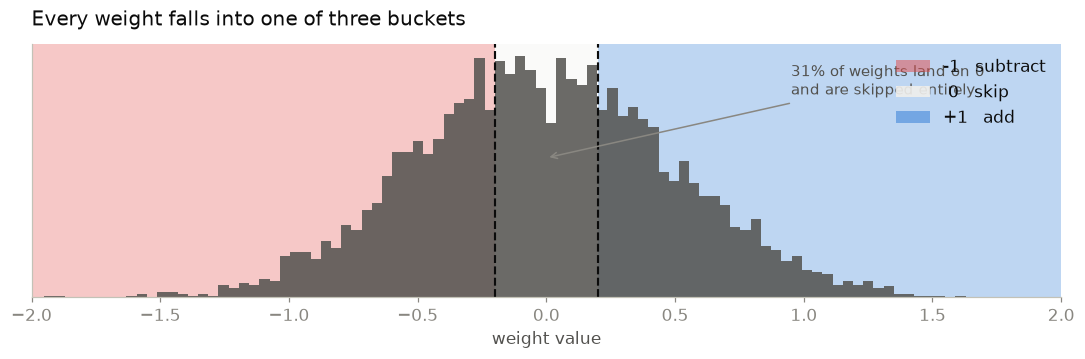

In [5]:

W = rng.normal(0, 0.5, 4000)
qW, sW = ternarize(W)
sW = sW.item()

fig, ax = plt.subplots(figsize=(10, 3.4))
for lo, hi, c, lab in [(-2.5, -sW/2, NEG, "-1  (subtract)"),
                       (-sW/2, sW/2, ZERO, "0  (skip)"),
                       (sW/2, 2.5, POS, "+1  (add)")]:
    ax.axvspan(lo, hi, color=c, alpha=0.30, lw=0)
ax.hist(W, bins=90, color=INK2, alpha=0.85, lw=0)
for cut in (-sW/2, sW/2):
    ax.axvline(cut, color=INK, lw=1.4, ls="--")

ax.set_xlim(-2, 2); ax.set_yticks([])
ax.set_xlabel("weight value")
ax.set_title("Every weight falls into one of three buckets", loc="left",
             fontsize=13, color=INK, pad=12)
ax.grid(False)
ax.legend(handles=[Patch(facecolor=NEG, alpha=.5, label="-1   subtract"),
                   Patch(facecolor=ZERO, alpha=.9, label=" 0   skip"),
                   Patch(facecolor=POS, alpha=.5, label="+1   add")],
          frameon=False, loc="upper right")
share_zero = (qW == 0).mean()
ax.annotate(f"{share_zero:.0%} of weights land on 0\nand are skipped entirely",
            xy=(0, ax.get_ylim()[1]*0.55), xytext=(0.95, ax.get_ylim()[1]*0.80),
            color=INK2, fontsize=10,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1))
plt.tight_layout(); plt.show()


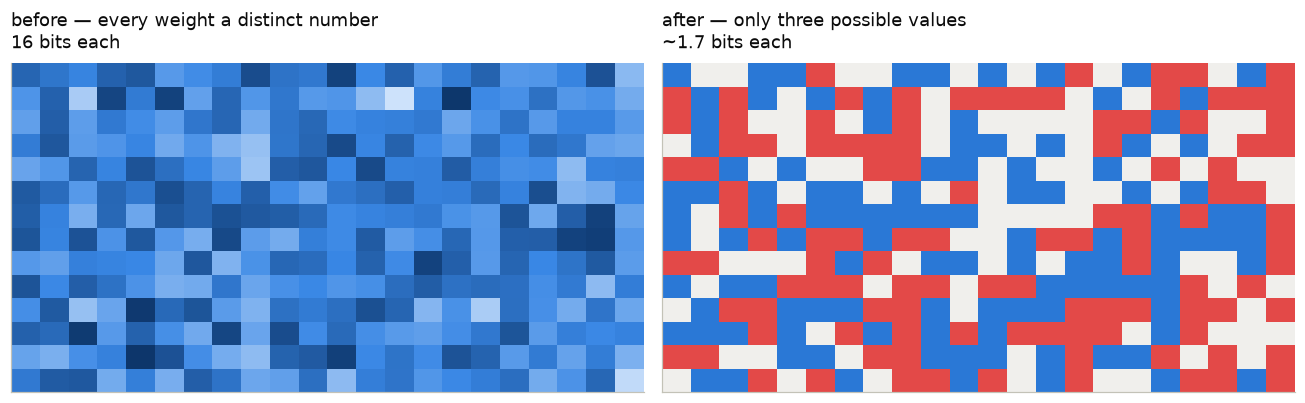

In [6]:

# The same thing on an actual weight matrix.
M = rng.normal(0, 0.5, (14, 22))
qM, sM = ternarize(M, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].imshow(M, cmap=SEQ, aspect="auto")
axes[0].set_title("before — every weight a distinct number\n16 bits each",
                  loc="left", fontsize=12, color=INK, pad=10)
axes[1].imshow(qM, cmap=TERN, vmin=-1, vmax=1, aspect="auto")
axes[1].set_title("after — only three possible values\n~1.7 bits each",
                  loc="left", fontsize=12, color=INK, pad=10)
for a in axes:
    a.set_xticks([]); a.set_yticks([]); a.grid(False)
plt.tight_layout(); plt.show()



---
## 3. Where "1.7 bits" comes from

Three possible values needs $\log_2 3 = 1.585$ bits, if you pack them efficiently
(the lazy way — 2 bits each — wastes a quarter of your space on a fourth state you
never use).

Then add the scales. You don't keep one scale for the whole model; you keep one per
small **group** of weights, because a single scale for 35 billion numbers would be a
terrible fit. With a group size of 128, each 16-bit scale is amortised over 128
weights.

Let's just compute it.


In [7]:

PARAMS   = 35e9
GROUP    = 128     # weights sharing one scale
SCALE_B  = 16      # bits per scale

ternary_bits = np.log2(3)
scale_bits   = SCALE_B / GROUP
total_bits   = ternary_bits + scale_bits

print(f"ternary payload      : {ternary_bits:.3f} bits/weight")
print(f"scale overhead       : {scale_bits:.3f} bits/weight  (16 bits per {GROUP})")
print(f"                       {'-'*22}")
print(f"total                : {total_bits:.3f} bits/weight   <- the claimed 1.7\n")

fp16_gb = PARAMS * 16 / 8 / 1e9
mach_gb = PARAMS * total_bits / 8 / 1e9
print(f"35B at 16 bits : {fp16_gb:5.1f} GB")
print(f"35B at {total_bits:.2f} bits : {mach_gb:5.1f} GB   ({fp16_gb/mach_gb:.1f}x smaller)")


ternary payload      : 1.585 bits/weight
scale overhead       : 0.125 bits/weight  (16 bits per 128)
                       ----------------------
total                : 1.710 bits/weight   <- the claimed 1.7

35B at 16 bits :  70.0 GB
35B at 1.71 bits :   7.5 GB   (9.4x smaller)



`1.710` — that is exactly the "1.7 bits per weight" in the announcement, and 7.5 GB
is their "7 GB". The arithmetic is self-consistent, which is a good sign that the
claim is at least internally honest.

### Why smaller means faster (the part most people skip)

Generating a token is **memory-bound, not compute-bound**. To produce *one* token the
GPU must read *every* weight in the model out of memory. So:

$$\text{tokens/sec} \;\approx\; \frac{\text{memory bandwidth}}{\text{bytes read per token}}$$

The multiply-free trick saves energy, but the 10× size cut is what buys the speed —
you're moving a tenth of the bytes.


In [8]:

for name, bw in [("laptop, ~M4 Pro class", 273),
                 ("laptop, ~M4 Max class", 546),
                 ("what 120 tok/s needs", 120 * mach_gb)]:
    print(f"{name:<24} {bw:6.0f} GB/s  ->  {bw/mach_gb:6.1f} tok/s")


laptop, ~M4 Pro class       273 GB/s  ->    36.5 tok/s
laptop, ~M4 Max class       546 GB/s  ->    73.0 tok/s
what 120 tok/s needs        898 GB/s  ->   120.0 tok/s



**A flag worth raising.** Their headline "up to 120 tokens per second" needs about
**900 GB/s** of memory bandwidth. That is not a typical consumer laptop — it's the
very top of the range. The "fits on consumer laptops" claim and the "120 tok/s"
claim are almost certainly describing *different machines*. Both can be true; they
just shouldn't be read as one sentence.

That took thirty seconds of arithmetic — it's the kind of check worth doing on any
launch post.



---
## 4. "But surely the errors cancel out?"

This is where almost everyone's intuition goes wrong, so let's test it rather than
argue about it.

The appealing story: each weight is badly wrong, but a dot product sums thousands of
terms, the errors are random and zero-mean, so they should wash out and the *sum*
should be accurate.

Let's measure the relative error as the vector gets longer.


mean distortion of one weight  : 45%
weights forced to zero         : 31%
dot-product error, n=4         : 44%
dot-product error, n=16384     : 50%


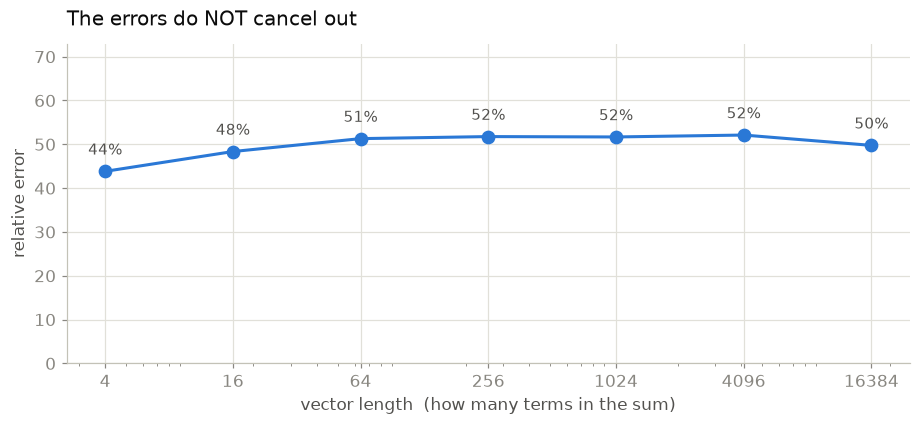

In [9]:

def rel_error_at(n, trials=600, rng=None):
    rng = rng or np.random.default_rng(1)
    X = rng.standard_normal((trials, n))
    W = rng.standard_normal((trials, n))
    q = np.clip(np.round(W / np.abs(W).mean(1, keepdims=True)), -1, 1)
    s = np.abs(W).mean(1, keepdims=True)
    exact  = (X * W).sum(1)
    approx = s.ravel() * (X * q).sum(1)
    # RMS of the error relative to the RMS of the signal (stable; a plain
    # |err|/|exact| blows up whenever a single dot product lands near zero)
    return np.sqrt(np.mean((approx - exact)**2)) / np.sqrt(np.mean(exact**2))

ns = [4, 16, 64, 256, 1024, 4096, 16384]
errs = [rel_error_at(n) for n in ns]

# For reference: how badly is a single weight mangled in the first place?
Wbig = rng.standard_normal(200_000)
sB = np.abs(Wbig).mean()
qB = np.clip(np.round(Wbig / sB), -1, 1)
print(f"mean distortion of one weight  : {np.abs(qB*sB - Wbig).mean()/np.abs(Wbig).mean():.0%}")
print(f"weights forced to zero         : {(qB == 0).mean():.0%}")
print(f"dot-product error, n=4         : {errs[0]:.0%}")
print(f"dot-product error, n=16384     : {errs[-1]:.0%}")

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(ns, [e*100 for e in errs], marker="o", ms=8, lw=2, color=BLUE)
for n, e in zip(ns, errs):
    ax.annotate(f"{e*100:.0f}%", (n, e*100), textcoords="offset points",
                xytext=(0, 11), ha="center", fontsize=10, color=INK2)
ax.set_xscale("log"); ax.set_xticks(ns)
ax.set_xticklabels([str(n) for n in ns])
ax.set_ylim(0, max(errs)*140)
ax.set_xlabel("vector length  (how many terms in the sum)")
ax.set_ylabel("relative error")
ax.set_title("The errors do NOT cancel out", loc="left", fontsize=13,
             color=INK, pad=12)
plt.tight_layout(); plt.show()



**Flat.** The error settles around 50% and stays there — summing 16,384 terms is no
more accurate than summing 4. (If anything it drifts slightly *up* before
plateauing.)

The reason is a nice piece of intuition: the *error* grows like $\sqrt{n}$ — but so
does the *signal*. Both are sums of random terms, so both grow at exactly the same
rate, and their ratio never moves. Averaging saves you nothing here.

So the compression really does mangle a typical weight by roughly **45%**, throwing
about a third of them away entirely — at any scale, with no amount of summing
rescuing it.

Which means claim 3 — "it still works" — cannot possibly come from the compression
being secretly accurate. **It has to come from somewhere else.**



---
## 5. So let's break a real network — and then fix it

Small enough to run in seconds, real enough to be honest: a 2-layer MLP learning the
classic two-moons boundary. We'll:

1. train it normally,
2. ternarize it and watch it degrade,
3. **retrain it while ternarized** — and watch it recover.

Step 3 is the actual product.


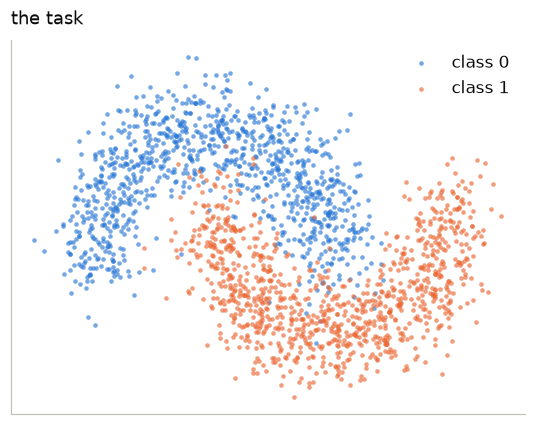

In [10]:

def make_moons(n, noise, rng):
    n_a = n // 2; n_b = n - n_a
    ta, tb = np.pi * rng.random(n_a), np.pi * rng.random(n_b)
    A = np.c_[np.cos(ta), np.sin(ta)]
    B = np.c_[1 - np.cos(tb), 0.5 - np.sin(tb)]
    X = np.vstack([A, B]) + noise * rng.standard_normal((n, 2))
    y = np.r_[np.zeros(n_a, int), np.ones(n_b, int)]
    p = rng.permutation(n)
    return X[p], y[p]

Xtr, ytr = make_moons(2000, 0.20, np.random.default_rng(7))
Xte, yte = make_moons(1000, 0.20, np.random.default_rng(8))
mu, sd = Xtr.mean(0), Xtr.std(0)
Xtr, Xte = (Xtr - mu) / sd, (Xte - mu) / sd

fig, ax = plt.subplots(figsize=(5, 4))
for c, col, lab in [(0, BLUE, "class 0"), (1, ORANGE, "class 1")]:
    m = ytr == c
    ax.scatter(Xtr[m, 0], Xtr[m, 1], s=9, color=col, alpha=.65, lw=0, label=lab)
ax.legend(frameon=False); ax.set_xticks([]); ax.set_yticks([])
ax.set_title("the task", loc="left", fontsize=12, color=INK, pad=10)
plt.tight_layout(); plt.show()


In [11]:

SIZES = [2, 64, 64, 2]

def init(rng):
    Ws = [rng.standard_normal((a, b)) * np.sqrt(2 / a)
          for a, b in zip(SIZES[:-1], SIZES[1:])]
    bs = [np.zeros(b) for b in SIZES[1:]]
    return Ws, bs

def forward(Ws, bs, X):
    hs, zs = [X], []
    h = X
    for i, (W, b) in enumerate(zip(Ws, bs)):
        z = h @ W + b
        zs.append(z)
        h = np.maximum(z, 0) if i < len(Ws) - 1 else z
        hs.append(h)
    return hs, zs

def loss_grad(logits, y):
    z = logits - logits.max(1, keepdims=True)
    p = np.exp(z); p /= p.sum(1, keepdims=True)
    loss = -np.log(p[np.arange(len(y)), y] + 1e-12).mean()
    g = p.copy(); g[np.arange(len(y)), y] -= 1.0
    return loss, g / len(y)

def backward(Ws, hs, zs, g):
    dW, db = [None]*len(Ws), [None]*len(Ws)
    for i in reversed(range(len(Ws))):
        dW[i] = hs[i].T @ g
        db[i] = g.sum(0)
        if i > 0:
            g = (g @ Ws[i].T) * (zs[i-1] > 0)
    return dW, db

def accuracy(Ws, bs, X, y):
    return (forward(Ws, bs, X)[0][-1].argmax(1) == y).mean()

def train(Ws, bs, steps, lr, quantize=False, rng=None, batch=256):
    rng = rng or np.random.default_rng(0)
    mW = [np.zeros_like(W) for W in Ws]; vW = [np.zeros_like(W) for W in Ws]
    mb = [np.zeros_like(b) for b in bs]; vb = [np.zeros_like(b) for b in bs]
    b1, b2, eps = 0.9, 0.999, 1e-8
    for t in range(1, steps + 1):
        idx = rng.integers(0, len(Xtr), batch)
        xb, yb = Xtr[idx], ytr[idx]
        # Straight-through estimator: run the forward pass on the QUANTIZED
        # weights, but apply the gradient to the underlying real ones. The
        # network therefore learns weights that survive being ternarized.
        Wf = [ternarize(W, axis=0)[0] * ternarize(W, axis=0)[1] for W in Ws] if quantize else Ws
        hs, zs = forward(Wf, bs, xb)
        _, g = loss_grad(hs[-1], yb)
        dW, db = backward(Wf, hs, zs, g)
        for i in range(len(Ws)):
            mW[i] = b1*mW[i] + (1-b1)*dW[i]; vW[i] = b2*vW[i] + (1-b2)*dW[i]**2
            mb[i] = b1*mb[i] + (1-b1)*db[i]; vb[i] = b2*vb[i] + (1-b2)*db[i]**2
            Ws[i] -= lr * (mW[i]/(1-b1**t)) / (np.sqrt(vW[i]/(1-b2**t)) + eps)
            bs[i] -= lr * (mb[i]/(1-b1**t)) / (np.sqrt(vb[i]/(1-b2**t)) + eps)
    return Ws, bs

def quantized_copy(Ws):
    out = []
    for W in Ws:
        q, s = ternarize(W, axis=0)
        out.append(q * s)
    return out

print("defined")


defined


In [12]:

# 1. train normally (full precision)
Ws, bs = init(np.random.default_rng(3))
Ws, bs = train(Ws, bs, steps=3000, lr=3e-3, rng=np.random.default_rng(4))
acc_fp = accuracy(Ws, bs, Xte, yte)

# 2. ternarize it, change nothing else
Wq = quantized_copy(Ws)
acc_naive = accuracy(Wq, bs, Xte, yte)

# 3. retrain WHILE ternarized (this is the <15 GPU-hours step, in miniature)
Wr = [W.copy() for W in Ws]; br = [b.copy() for b in bs]
Wr, br = train(Wr, br, steps=3000, lr=1e-3, quantize=True,
               rng=np.random.default_rng(5))
acc_qat = accuracy(quantized_copy(Wr), br, Xte, yte)

print(f"full precision            : {acc_fp*100:5.1f}%")
print(f"ternarized, no retraining : {acc_naive*100:5.1f}%   <- degraded")
print(f"ternarized + retrained    : {acc_qat*100:5.1f}%   <- recovered")
print(f"\nrecovery: {acc_qat/acc_fp*100:.1f}% of the original model's accuracy")


full precision            :  96.5%
ternarized, no retraining :  89.9%   <- degraded
ternarized + retrained    :  96.4%   <- recovered

recovery: 99.9% of the original model's accuracy


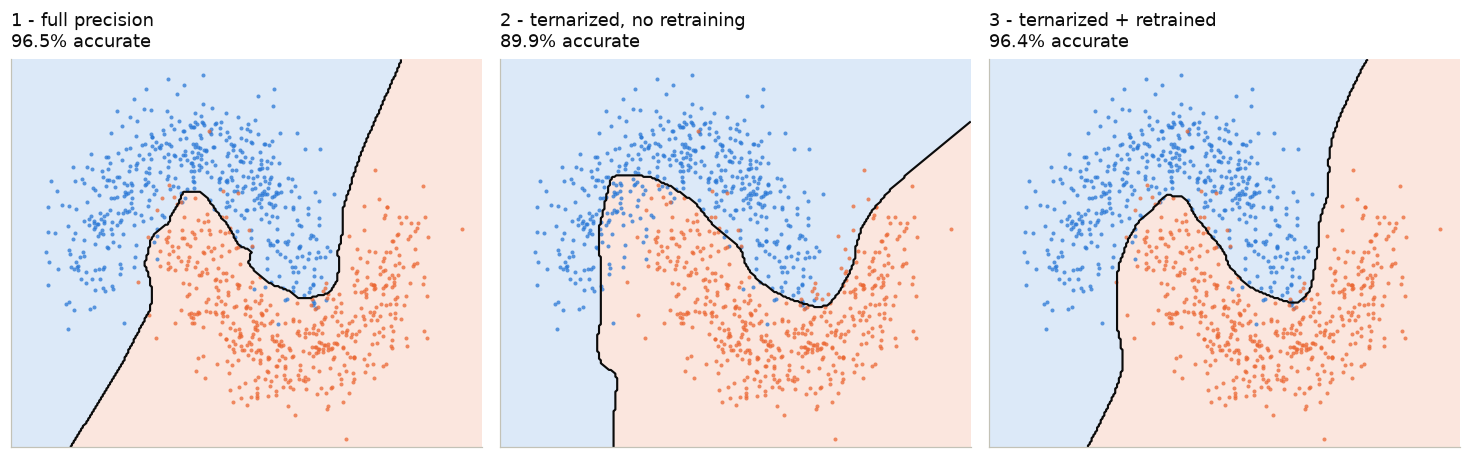

In [13]:

def boundary(Wlist, blist, ax, title, acc):
    g = np.linspace(-2.6, 2.6, 260)
    XX, YY = np.meshgrid(g, g)
    P = forward(Wlist, blist, np.c_[XX.ravel(), YY.ravel()])[0][-1]
    Z = P.argmax(1).reshape(XX.shape)
    ax.contourf(XX, YY, Z, levels=[-.5, .5, 1.5], colors=[BLUE, ORANGE], alpha=.16)
    ax.contour(XX, YY, Z, levels=[.5], colors=[INK], linewidths=1.4)
    for c, col in [(0, BLUE), (1, ORANGE)]:
        m = yte == c
        ax.scatter(Xte[m, 0], Xte[m, 1], s=7, color=col, alpha=.75, lw=0)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    ax.set_title(f"{title}\n{acc*100:.1f}% accurate", loc="left",
                 fontsize=11.5, color=INK, pad=8)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.3))
boundary(Ws, bs, axes[0], "1 - full precision", acc_fp)
boundary(Wq, bs, axes[1], "2 - ternarized, no retraining", acc_naive)
boundary(quantized_copy(Wr), br, axes[2], "3 - ternarized + retrained", acc_qat)
plt.tight_layout(); plt.show()


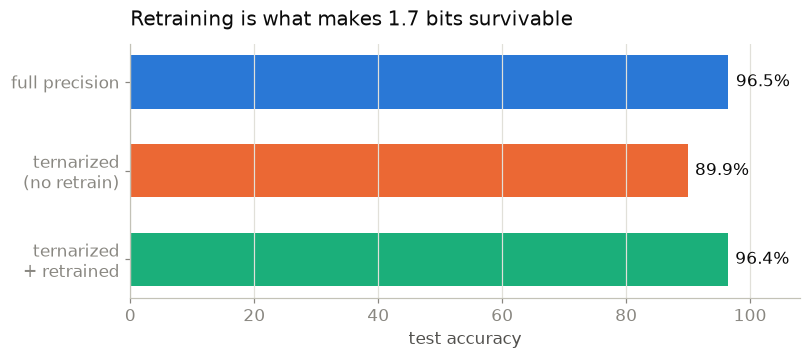

In [14]:

fig, ax = plt.subplots(figsize=(7.5, 3.4))
names = ["full precision", "ternarized\n(no retrain)", "ternarized\n+ retrained"]
vals  = [acc_fp*100, acc_naive*100, acc_qat*100]
cols  = [BLUE, ORANGE, AQUA]
bars = ax.barh(names, vals, color=cols, height=.6)
for b, v in zip(bars, vals):
    ax.text(v + 1.2, b.get_y() + b.get_height()/2, f"{v:.1f}%",
            va="center", fontsize=11, color=INK)
ax.set_xlim(0, 108); ax.invert_yaxis()
ax.set_xlabel("test accuracy")
ax.grid(axis="y", visible=False)
ax.set_title("Retraining is what makes 1.7 bits survivable", loc="left",
             fontsize=13, color=INK, pad=12)
plt.tight_layout(); plt.show()



---
## 6. What you just saw, and what it means for the claim

The middle panel is the whole point. Compress a trained network naively and the
boundary buckles — it goes ragged exactly where the two moons interlock, because we
mangled every weight by ~45% and, as section 4 proved, nothing rescues that
automatically.

Be precise about the size of that damage, though: accuracy fell from ~96.5% to
~90%, which is **not** a broken model — it's a model whose *error rate roughly
tripled* (3.5% → 10%). That's the honest shape of naive quantization on an easy
task. On a hard one — long agentic generations, where each step's error feeds the
next — a 3× error rate is the difference between a model that finishes a task and
one that derails halfway.

Retrain it *while it is compressed*, and it comes back. The network doesn't recover
the original weights; it finds **different** weights that happen to work when
ternarized. The trick that makes this possible is the **straight-through estimator**
in `train()`: forward pass uses the ternary weights (so the network feels the damage),
backward pass updates the underlying real-valued weights (so learning still has
somewhere smooth to move).

### So which part of Mach-1 is actually new?

Ternary weights are not new — that's **BitNet**, published in 2023/24 and well
understood. Its problem was always cost: BitNet essentially wants to be **pretrained
from scratch** in ternary. At frontier scale that's a full pretraining run, which is
why the idea never made it past small models despite obviously working.

Syzygy's claim is that they can convert an **already-trained** model in **under 15
GPU-hours**. That's the load-bearing sentence in the whole announcement — the
difference between "a way to build models" and "a pass you can run on anyone's
checkpoint". It's also what licenses their promise of 3-trillion-parameter models
"in the coming weeks", since nothing there requires a pretraining budget.

### What to hold back on

- **"95% recovery"** is self-reported, across 12 unnamed benchmarks, with no paper
  and no independent eval. Section 5 shows recovery is real and achievable — it does
  not show it's 95% on agentic tasks, which is where long generations let small
  per-step errors compound.
- **The base model is Qwen 3.6 35B** — mid-tier and *dense*. A 3T model is sparse
  (MoE), and expert routing is far more sensitive to weight precision than a dense
  matmul: a routing decision is a hard argmax, so a small perturbation can send a
  token to a completely different expert. Scaling this is not obviously free.
- **The bandwidth arithmetic** in section 3 suggests "consumer laptop" and
  "120 tok/s" are different machines.
- **15 GPU-hours is unverified**, and it's the one number everything else rests on.

### The one-sentence version

> Force every weight to be −1, 0 or +1 so multiplication becomes addition and the
> model shrinks 10×; this badly damages the network, so **retrain it in its damaged
> form until it learns to work anyway** — and the real claim is that this retraining
> now costs 15 GPU-hours instead of a pretraining run.

---
### Things to try

- Set `GROUP = 32` in section 3 — how much does the scale overhead cost you?
- In section 5, drop the retrain to `steps=200`. How fast does accuracy come back?
- Try **binary** instead of ternary (`np.sign(W)`, no zero bucket). Worse — why?
  (Hint: look at how many weights were landing on 0.)
- Ternarize only the *first* layer, or only the last. Which one hurts more?
